In [1]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Product Monthly Panel dataset
file_path = 'product_monthly_panel.csv'
product_df = pd.read_csv(file_path)

# Display the first few rows
print("First five rows of the dataset:")
print(product_df.head())

# Selecting relevant categorical columns for association analysis
categorical_cols = ['brand_name', 'skin_type', 'skin_tone', 'eye_color', 'hair_color']
product_categorical = product_df[categorical_cols].dropna()

# Convert categorical data into a list of transactions
transactions = product_categorical.apply(lambda x: list(x.dropna()), axis=1).tolist()




First five rows of the dataset:
  product_id submission_time  rating  is_recommended  helpfulness  \
0    P107306      2008-09-30     4.0             NaN     0.883333   
1    P107306      2008-10-31     4.5             NaN     0.833333   
2    P107306      2008-11-30     1.0             NaN     0.833333   
3    P107306      2008-12-31     4.5             NaN     0.750000   
4    P107306      2009-01-31     5.0             NaN     0.833333   

   total_feedback_count  total_neg_feedback_count  total_pos_feedback_count  \
0                    15                         2                        13   
1                     6                         1                         5   
2                     6                         1                         5   
3                     6                         1                         5   
4                     8                         2                         6   

   price_usd brand_name  skin_tone eye_color    skin_type hair_color  
0      

In [2]:
# Encode transactions using TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)


In [3]:
# Apply the Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)

# Display frequent itemsets
print("\nFrequent Itemsets:")
print(frequent_itemsets)


Frequent Itemsets:
     support                           itemsets
0   0.221529                            (black)
1   0.242936                           (blonde)
2   0.198637                             (blue)
3   0.717714                            (brown)
4   0.540954                      (combination)
5   0.200595                              (dry)
6   0.233583                             (fair)
7   0.067137                        (fairLight)
8   0.137554                            (green)
9   0.132461                            (hazel)
10  0.288793                            (light)
11  0.203005                      (lightMedium)
12  0.070218                           (medium)
13  0.067717                        (mediumTan)
14  0.135742                           (normal)
15  0.122709                             (oily)
16  0.196933                     (black, brown)
17  0.122075               (black, combination)
18  0.050316               (lightMedium, black)
19  0.106759        

In [4]:
# Generate association rules with a minimum confidence of 0.6
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.6)

# Display association rules
print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])



Association Rules:
                   antecedents consequents   support  confidence      lift
0                      (black)     (brown)  0.196933    0.888971  1.238614
1                (combination)     (brown)  0.392561    0.725683  1.011103
2                        (dry)     (brown)  0.139131    0.693594  0.966393
3                      (light)     (brown)  0.192601    0.666918  0.929225
4                (lightMedium)     (brown)  0.168603    0.830536  1.157196
5                     (medium)     (brown)  0.062261    0.886680  1.235423
6                  (mediumTan)     (brown)  0.063095    0.931745  1.298212
7                     (normal)     (brown)  0.091062    0.670851  0.934705
8                       (oily)     (brown)  0.094959    0.773855  1.078222
9         (black, combination)     (brown)  0.109605    0.897847  1.250982
10        (combination, light)     (brown)  0.106324    0.673170  0.937936
11  (lightMedium, combination)     (brown)  0.095213    0.832620  1.160100


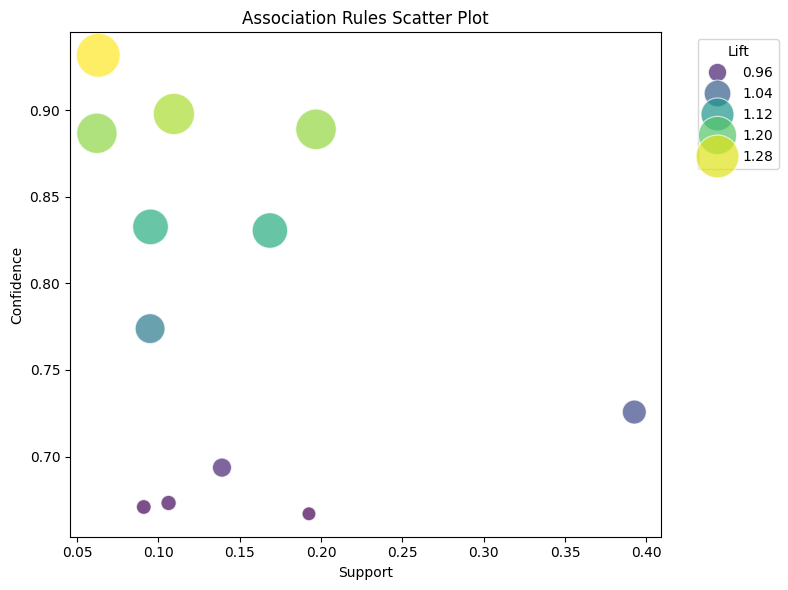

In [5]:
# Visualizing association rules
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='support',
    y='confidence',
    size='lift',
    data=rules,
    hue='lift',
    palette='viridis',
    sizes=(100, 1000),
    alpha=0.7
)
plt.title('Association Rules Scatter Plot')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [6]:
# Display top association rules sorted by lift
sorted_rules = rules.sort_values(by='lift', ascending=False)
print("\nTop Association Rules Sorted by Lift:")
print(sorted_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])



Top Association Rules Sorted by Lift:
                   antecedents consequents   support  confidence      lift
6                  (mediumTan)     (brown)  0.063095    0.931745  1.298212
9         (black, combination)     (brown)  0.109605    0.897847  1.250982
0                      (black)     (brown)  0.196933    0.888971  1.238614
5                     (medium)     (brown)  0.062261    0.886680  1.235423
11  (lightMedium, combination)     (brown)  0.095213    0.832620  1.160100
4                (lightMedium)     (brown)  0.168603    0.830536  1.157196
8                       (oily)     (brown)  0.094959    0.773855  1.078222
1                (combination)     (brown)  0.392561    0.725683  1.011103
2                        (dry)     (brown)  0.139131    0.693594  0.966393
10        (combination, light)     (brown)  0.106324    0.673170  0.937936
7                     (normal)     (brown)  0.091062    0.670851  0.934705
3                      (light)     (brown)  0.192601    0.666